Importing Dependencies

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [2]:
creditcard_data = pd.read_csv('creditcard.csv')

In [3]:
creditcard_data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [4]:
creditcard_data.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
283140,171397.0,-0.254333,0.494893,0.783833,-0.894191,0.553898,-1.230924,1.161303,-0.393764,-0.193330,...,-0.151866,-0.360438,0.092942,0.536912,-0.600539,-0.059604,-0.318109,-0.144452,16.00,0.0
283141,171398.0,-0.943864,0.836655,0.292689,-0.723866,0.873360,0.545275,0.710274,0.602397,-0.636504,...,-0.017617,-0.077826,0.056577,-1.008943,-0.290398,0.373463,-0.033192,0.033956,44.72,0.0
283142,171398.0,-2.149728,1.810804,-1.509192,-0.693237,0.415451,-0.875696,0.531266,-0.032141,1.019081,...,-0.306518,-0.947940,0.369640,0.445435,-0.356238,0.016897,-1.064181,0.329735,10.98,0.0
283143,171399.0,-0.612184,1.263673,2.083651,2.499148,0.825444,0.786503,0.913700,-0.061163,-1.199105,...,-0.221725,-0.591816,-0.140595,-0.739479,-0.333499,-0.374199,-0.167668,-0.084052,37.95,0.0
283144,171400.0,1.209070,-2.338353,-4.422113,-1.100578,2.146988,2.885949,0.657054,0.267981,-1.383349,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
creditcard_data.shape

(283145, 31)

In [6]:
creditcard_data.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,283145.000000,283145.000000,283145.000000,283145.000000,283145.000000,283145.000000,283145.000000,283145.000000,283145.000000,283145.000000,...,283144.000000,283144.000000,283144.000000,283144.000000,283144.000000,283144.000000,283144.000000,283144.000000,283144.000000,283144.000000
mean,94360.470738,-0.000492,-0.002182,0.004469,0.000739,-0.001600,0.000802,-0.001125,-0.000248,-0.000191,...,-0.000076,-0.000503,-0.000212,-0.000086,0.000775,-0.000009,-0.000072,0.000023,88.456790,0.001738
std,47256.049483,1.958663,1.651813,1.515287,1.415901,1.379165,1.331407,1.235181,1.195086,1.099068,...,0.735626,0.725335,0.625197,0.605799,0.520999,0.482381,0.403745,0.330306,249.743529,0.041649
min,0.000000,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-43.557242,-73.216718,-13.434066,...,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-15.430084,0.000000,0.000000
25%,54019.000000,-0.920446,-0.599797,-0.883909,-0.848815,-0.693752,-0.767288,-0.554708,-0.208134,-0.643811,...,-0.228221,-0.541851,-0.161945,-0.354572,-0.316244,-0.327180,-0.070815,-0.052878,5.640000,0.000000
50%,84394.000000,0.018481,0.064546,0.184545,-0.018655,-0.056567,-0.272917,0.038918,0.022594,-0.052016,...,-0.029544,0.006549,-0.011438,0.041129,0.018047,-0.052484,0.001421,0.011345,22.000000,0.000000
75%,138823.000000,1.314410,0.802027,1.030211,0.745603,0.609922,0.399623,0.569274,0.327221,0.597638,...,0.185975,0.527208,0.147276,0.439107,0.351315,0.241331,0.090903,0.078218,77.500000,0.000000
max,171400.000000,2.454930,22.057729,9.382558,16.875344,34.801666,73.301626,120.589494,20.007208,15.594995,...,27.202839,10.503090,22.528412,4.584549,7.519589,3.517346,31.612198,33.847808,25691.160000,1.000000


In [7]:
creditcard_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 283145 entries, 0 to 283144
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    283145 non-null  float64
 1   V1      283145 non-null  float64
 2   V2      283145 non-null  float64
 3   V3      283145 non-null  float64
 4   V4      283145 non-null  float64
 5   V5      283145 non-null  float64
 6   V6      283145 non-null  float64
 7   V7      283145 non-null  float64
 8   V8      283145 non-null  float64
 9   V9      283145 non-null  float64
 10  V10     283145 non-null  float64
 11  V11     283145 non-null  float64
 12  V12     283145 non-null  float64
 13  V13     283145 non-null  float64
 14  V14     283145 non-null  float64
 15  V15     283144 non-null  float64
 16  V16     283144 non-null  float64
 17  V17     283144 non-null  float64
 18  V18     283144 non-null  float64
 19  V19     283144 non-null  float64
 20  V20     283144 non-null  float64
 21  V21     28

In [8]:
creditcard_data.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [9]:
creditcard_data = creditcard_data.dropna()

In [10]:
creditcard_data.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [11]:
creditcard_data.shape

(283144, 31)

In [12]:
creditcard_data['Class'].value_counts()

,count
Class,
0.0,282652
1.0,492


# This dataset is highly Unbalanced

0 -> Normal Transcation

1 -> Fraudulent Transcation

In [13]:
legit = creditcard_data[creditcard_data.Class == 0]
fraud = creditcard_data[creditcard_data.Class == 1]

In [14]:
print(legit.shape)
print(fraud.shape)

(282652, 31)
(492, 31)


In [15]:
#stastistical measure of data
legit.Amount.describe()

,Amount
count,282652.000000
mean,88.398035
std,249.727771
min,0.000000
25%,5.690000
50%,22.000000
75%,77.350000
max,25691.160000


In [16]:
fraud.Amount.describe()

,Amount
count,492.000000
mean,122.211321
std,256.683288
min,0.000000
25%,1.000000
50%,9.250000
75%,105.890000
max,2125.870000


In [17]:
# Compare the value for both Transcations
creditcard_data.groupby('Class').mean()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
Class,,,,,,,,,,,,,,,,,,,,,
0.0,94383.894888,0.007809,-0.008485,0.016735,-0.007162,0.003875,0.003227,0.008564,-0.001242,0.004306,...,-0.000557,-0.001318,-0.000528,-0.000142,0.000097,0.000705,-0.000099,-0.000369,-0.000109,88.398035
1.0,80746.806911,-4.771948,3.623778,-7.033281,4.542029,-3.151225,-1.397737,-5.568731,0.570636,-2.581123,...,0.372319,0.713588,0.014049,-0.040308,-0.105130,0.041449,0.051648,0.170575,0.075667,122.211321


# Under Sampling

Build a sample dataset containing similar distribution of normal Transcation and Fraudulent Transcation

no of fraudulent transcation

In [18]:
legit_sample = legit.sample(n=492)

In [19]:
#concatinating two dataFrames

new_dataset = pd.concat([legit_sample, fraud], axis=0)

In [20]:
new_dataset.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
257233,158062.0,-0.090258,1.141390,-0.638817,-0.795633,1.068887,-0.332064,0.841084,0.082510,-0.057278,...,-0.346932,-0.827931,0.053428,0.166251,-0.360468,0.122153,0.323382,0.129386,2.69,0.0
245542,152796.0,2.136662,-0.434177,-1.716698,-0.928290,0.156958,-0.631018,-0.071869,-0.083703,0.884312,...,-0.329453,-0.968679,0.235597,-1.124467,-0.342002,0.594263,-0.119242,-0.091571,4.00,0.0
182113,125261.0,-0.333941,0.212910,-0.038728,-0.485864,1.253315,1.015050,0.865770,0.320387,-0.151013,...,0.010310,0.007956,0.379257,-0.362665,-1.084327,0.291948,0.165183,0.208751,84.27,0.0
121022,76046.0,-2.390363,1.231639,0.213914,-0.270630,0.190434,0.154506,0.675915,0.120588,0.229934,...,-0.022003,0.569556,0.184524,-0.289541,-0.556989,0.105079,-1.778099,-1.146543,36.18,0.0
277228,167532.0,2.061512,-0.901403,-0.675069,-0.840649,-0.568549,0.298587,-0.902480,0.091087,-0.193616,...,-0.553995,-1.058312,0.430923,0.173111,-0.560330,-0.349605,0.026800,-0.034004,31.00,0.0


In [21]:
new_dataset.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
279863,169142.0,-1.927883,1.125653,-4.518331,1.749293,-1.566487,-2.010494,-0.882850,0.697211,-2.064945,...,0.778584,-0.319189,0.639419,-0.294885,0.537503,0.788395,0.292680,0.147968,390.00,1.0
280143,169347.0,1.378559,1.289381,-5.004247,1.411850,0.442581,-1.326536,-1.413170,0.248525,-1.127396,...,0.370612,0.028234,-0.145640,-0.081049,0.521875,0.739467,0.389152,0.186637,0.76,1.0
280149,169351.0,-0.676143,1.126366,-2.213700,0.468308,-1.120541,-0.003346,-2.234739,1.210158,-0.652250,...,0.751826,0.834108,0.190944,0.032070,-0.739695,0.471111,0.385107,0.194361,77.89,1.0
281144,169966.0,-3.113832,0.585864,-5.399730,1.817092,-0.840618,-2.943548,-2.208002,1.058733,-1.632333,...,0.583276,-0.269209,-0.456108,-0.183659,-0.328168,0.606116,0.884876,-0.253700,245.00,1.0
281674,170348.0,1.991976,0.158476,-2.583441,0.408670,1.151147,-0.096695,0.223050,-0.068384,0.577829,...,-0.164350,-0.295135,-0.072173,-0.450261,0.313267,-0.289617,0.002988,-0.015309,42.53,1.0


In [22]:
new_dataset.value_counts('Class')

,count
Class,
0.0,492
1.0,492


In [23]:
new_dataset.groupby('Class').mean()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
Class,,,,,,,,,,,,,,,,,,,,,
0.0,96686.262195,0.139487,0.030011,-0.042520,-0.053090,0.002791,-0.029627,-0.060555,-0.004313,0.004320,...,-0.043800,-0.023926,-0.008291,0.035401,-0.051296,-0.018797,-0.020155,-0.014446,-0.012044,67.555488
1.0,80746.806911,-4.771948,3.623778,-7.033281,4.542029,-3.151225,-1.397737,-5.568731,0.570636,-2.581123,...,0.372319,0.713588,0.014049,-0.040308,-0.105130,0.041449,0.051648,0.170575,0.075667,122.211321


In [24]:
X = new_dataset.drop(columns = "Class" , axis=1)
Y = new_dataset['Class']

In [25]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=2)

In [26]:
model = LogisticRegression()

In [27]:
model.fit(X_train, Y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [28]:
training_data_prediction = model.predict(X_train)
training_data_accuracy = accuracy_score(training_data_prediction, Y_train)
print("training data accuracy : " ,training_data_accuracy)

training data accuracy :  0.951715374841169


In [29]:
test_data_prediction = model.predict(X_test)
test_data_accuracy = accuracy_score(test_data_prediction, Y_test)
print("test data accuracy : " ,test_data_accuracy)

test data accuracy :  0.9137055837563451


In [30]:
print(classification_report(Y_test, test_data_prediction))

              precision    recall  f1-score   support

         0.0       0.89      0.94      0.92        99
         1.0       0.94      0.89      0.91        98

    accuracy                           0.91       197
   macro avg       0.91      0.91      0.91       197
weighted avg       0.91      0.91      0.91       197



In [31]:
print(confusion_matrix(Y_test, test_data_prediction))

[[93  6]
 [11 87]]


# 1. Random Oversampling

In [32]:
# Original Dataset
X = creditcard_data.drop(columns='Class', axis=1)
Y = creditcard_data['Class']

# Train Test Split
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.2,stratify=Y,random_state=2)

In [33]:
from imblearn.over_sampling import RandomOverSampler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Random Oversampling
ros = RandomOverSampler(random_state=2)

X_resampled, Y_resampled = ros.fit_resample(X_train, Y_train)

# Class Count
print(Y_resampled.value_counts())

# Model
model = LogisticRegression(max_iter=1000)

model.fit(X_resampled, Y_resampled)

# Prediction
Y_pred = model.predict(X_test)

# Evaluation
print("Accuracy :", accuracy_score(Y_test, Y_pred))

print("\nClassification Report\n")
print(classification_report(Y_test, Y_pred))

print("\nConfusion Matrix\n")
print(confusion_matrix(Y_test, Y_pred))

Class
0.0    226121
1.0    226121
Name: count, dtype: int64
Accuracy : 0.9748362146603331

Classification Report

              precision    recall  f1-score   support

         0.0       1.00      0.97      0.99     56531
         1.0       0.06      0.92      0.11        98

    accuracy                           0.97     56629
   macro avg       0.53      0.95      0.55     56629
weighted avg       1.00      0.97      0.99     56629


Confusion Matrix

[[55114  1417]
 [    8    90]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# 2. SMOTE

In [34]:
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# SMOTE
smote = SMOTE(random_state=2)

X_resampled, Y_resampled = smote.fit_resample(X_train, Y_train)

# Class Count
print(Y_resampled.value_counts())

# Model
model = LogisticRegression(max_iter=1000)

model.fit(X_resampled, Y_resampled)

# Prediction
Y_pred = model.predict(X_test)

# Evaluation
print("Accuracy :", accuracy_score(Y_test, Y_pred))

print("\nClassification Report\n")
print(classification_report(Y_test, Y_pred))

print("\nConfusion Matrix\n")
print(confusion_matrix(Y_test, Y_pred))

Class
0.0    226121
1.0    226121
Name: count, dtype: int64
Accuracy : 0.9892281339949496

Classification Report

              precision    recall  f1-score   support

         0.0       1.00      0.99      0.99     56531
         1.0       0.13      0.90      0.22        98

    accuracy                           0.99     56629
   macro avg       0.56      0.94      0.61     56629
weighted avg       1.00      0.99      0.99     56629


Confusion Matrix

[[55931   600]
 [   10    88]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# 3. ADASYN

In [35]:
from imblearn.over_sampling import ADASYN
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ADASYN
adasyn = ADASYN(random_state=2)

X_resampled, Y_resampled = adasyn.fit_resample(X_train, Y_train)

# Class Count
print(Y_resampled.value_counts())

# Model
model = LogisticRegression(max_iter=1000)

model.fit(X_resampled, Y_resampled)

# Prediction
Y_pred = model.predict(X_test)

# Evaluation
print("Accuracy :", accuracy_score(Y_test, Y_pred))

print("\nClassification Report\n")
print(classification_report(Y_test, Y_pred))

print("\nConfusion Matrix\n")
print(confusion_matrix(Y_test, Y_pred))

Class
0.0    226121
1.0    226077
Name: count, dtype: int64
Accuracy : 0.988044994614067

Classification Report

              precision    recall  f1-score   support

         0.0       1.00      0.99      0.99     56531
         1.0       0.12      0.90      0.21        98

    accuracy                           0.99     56629
   macro avg       0.56      0.94      0.60     56629
weighted avg       1.00      0.99      0.99     56629


Confusion Matrix

[[55864   667]
 [   10    88]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# 4. SMOTE + TOMEK LINKS

In [36]:
from imblearn.combine import SMOTETomek
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# SMOTE + Tomek
smt = SMOTETomek(random_state=2)

X_resampled, Y_resampled = smt.fit_resample(X_train, Y_train)

# Class Count
print(Y_resampled.value_counts())

# Model
model = LogisticRegression(max_iter=1000)

model.fit(X_resampled, Y_resampled)

# Prediction
Y_pred = model.predict(X_test)

# Evaluation
print("Accuracy :", accuracy_score(Y_test, Y_pred))

print("\nClassification Report\n")
print(classification_report(Y_test, Y_pred))

print("\nConfusion Matrix\n")
print(confusion_matrix(Y_test, Y_pred))

Class
0.0    225374
1.0    225374
Name: count, dtype: int64
Accuracy : 0.9897225803033781

Classification Report

              precision    recall  f1-score   support

         0.0       1.00      0.99      0.99     56531
         1.0       0.13      0.90      0.23        98

    accuracy                           0.99     56629
   macro avg       0.57      0.94      0.61     56629
weighted avg       1.00      0.99      0.99     56629


Confusion Matrix

[[55959   572]
 [   10    88]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# 5. SMOTEENN

In [37]:
from imblearn.combine import SMOTEENN
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# SMOTEENN
smote_enn = SMOTEENN(random_state=2)

X_resampled, Y_resampled = smote_enn.fit_resample(X_train, Y_train)

# Class Count
print(Y_resampled.value_counts())

# Model
model = LogisticRegression(max_iter=1000)

model.fit(X_resampled, Y_resampled)

# Prediction
Y_pred = model.predict(X_test)

# Evaluation
print("Accuracy :", accuracy_score(Y_test, Y_pred))

print("\nClassification Report\n")
print(classification_report(Y_test, Y_pred))

print("\nConfusion Matrix\n")
print(confusion_matrix(Y_test, Y_pred))

Class
1.0    216714
0.0    206835
Name: count, dtype: int64
Accuracy : 0.9899521446608628

Classification Report

              precision    recall  f1-score   support

         0.0       1.00      0.99      0.99     56531
         1.0       0.14      0.90      0.24        98

    accuracy                           0.99     56629
   macro avg       0.57      0.94      0.62     56629
weighted avg       1.00      0.99      0.99     56629


Confusion Matrix

[[55972   559]
 [   10    88]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# 6. NEARMISS (SMART UNDERSAMPLING)

In [38]:
from imblearn.under_sampling import NearMiss
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# NearMiss
nm = NearMiss()

X_resampled, Y_resampled = nm.fit_resample(X_train, Y_train)

# Class Count
print(Y_resampled.value_counts())

# Model
model = LogisticRegression(max_iter=1000)

model.fit(X_resampled, Y_resampled)

# Prediction
Y_pred = model.predict(X_test)

# Evaluation
print("Accuracy :", accuracy_score(Y_test, Y_pred))

print("\nClassification Report\n")
print(classification_report(Y_test, Y_pred))

print("\nConfusion Matrix\n")
print(confusion_matrix(Y_test, Y_pred))

Class
0.0    394
1.0    394
Name: count, dtype: int64
Accuracy : 0.710572321602006

Classification Report

              precision    recall  f1-score   support

         0.0       1.00      0.71      0.83     56531
         1.0       0.01      0.95      0.01        98

    accuracy                           0.71     56629
   macro avg       0.50      0.83      0.42     56629
weighted avg       1.00      0.71      0.83     56629


Confusion Matrix

[[40146 16385]
 [    5    93]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


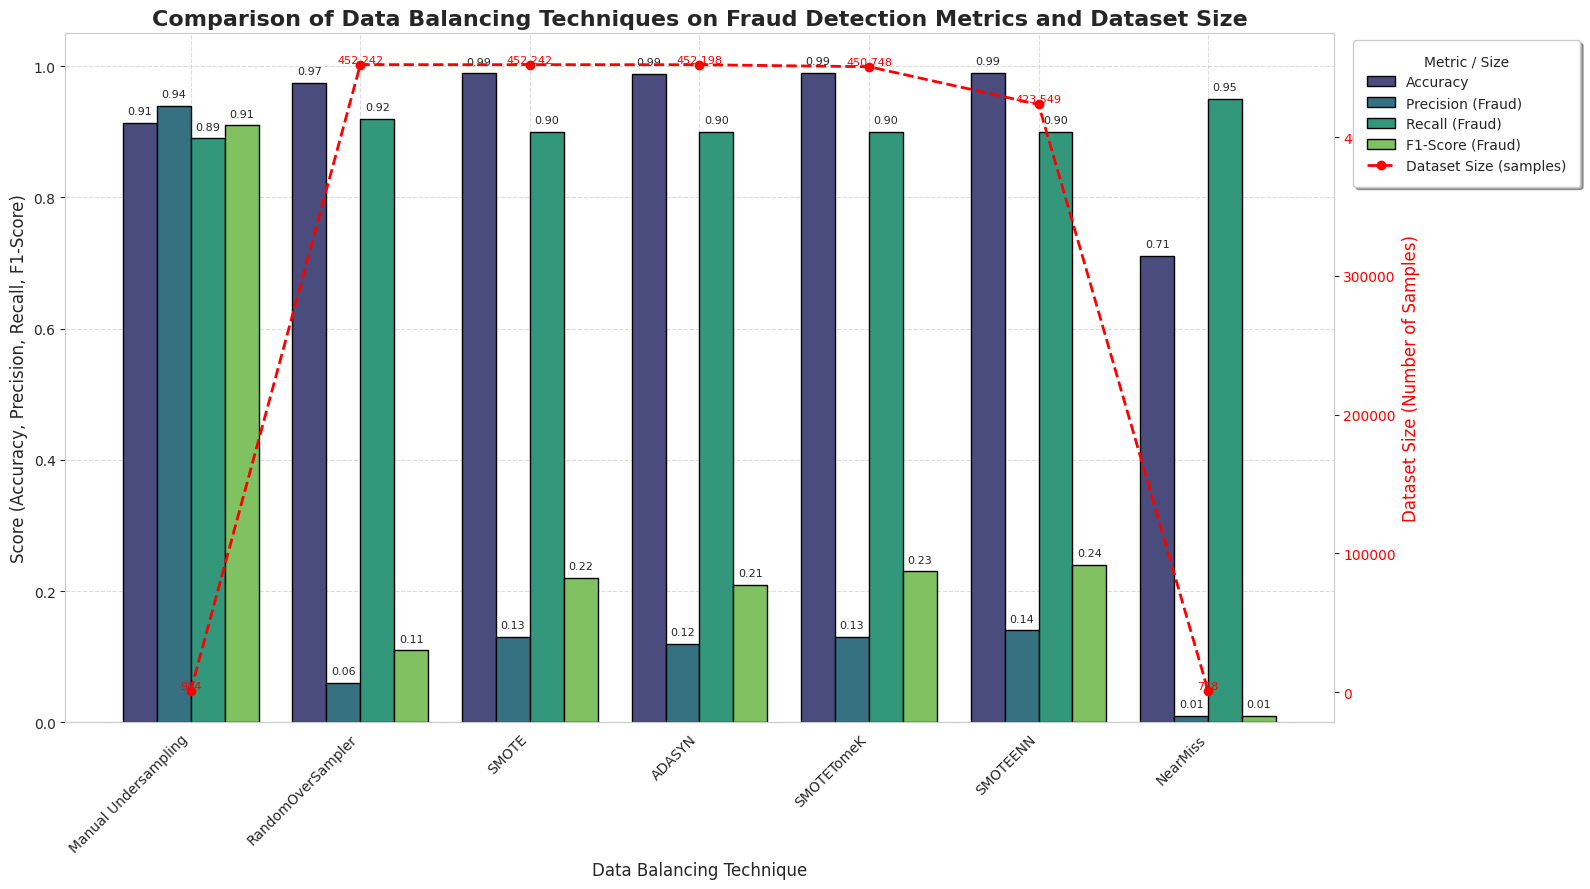

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Data extracted from previous cell outputs for each technique
techniques = [
    'Manual Undersampling',
    'RandomOverSampler',
    'SMOTE',
    'ADASYN',
    'SMOTETomeK',
    'SMOTEENN',
    'NearMiss'
]

# Overall Accuracy scores (from previous cell outputs)
accuracies = [0.9137, 0.9748, 0.9892, 0.9880, 0.9897, 0.9899, 0.7106]

# Precision, Recall, and F1-scores specifically for the fraudulent class (Class 1.0) (from previous cell outputs)
precisions_fraud = [0.94, 0.06, 0.13, 0.12, 0.13, 0.14, 0.01]
recales_fraud = [0.89, 0.92, 0.90, 0.90, 0.90, 0.90, 0.95]
f1_scores_fraud = [0.91, 0.11, 0.22, 0.21, 0.23, 0.24, 0.01]

# Dataset sizes for each technique, derived from previous cell outputs' Y_resampled.value_counts()
# Manual Undersampling: 492 + 492 = 984 (from new_dataset.shape in NhnHuwtq_RoC)
# RandomOverSampler: 226121 + 226121 = 452242 (from AGYddxib8APz)
# SMOTE: 226121 + 226121 = 452242 (from ZI0dntbcBpdg)
# ADASYN: 226121 + 226077 = 452198 (from VMD457zvDjc3)
# SMOTETomeK: 225374 + 225374 = 450748 (from kBYX7B53DjQZ)
# SMOTEENN: 216714 + 206835 = 423549 (from UH0e67VVDqC_)
# NearMiss: 394 + 394 = 788 (from xFvTZZOBD4MB)
dataset_sizes = [984, 452242, 452242, 452198, 450748, 423549, 788]

# Create a DataFrame for easier plotting
data_for_plot = pd.DataFrame({
    'Technique': techniques,
    'Accuracy': accuracies,
    'Precision (Fraud)': precisions_fraud,
    'Recall (Fraud)': recales_fraud,
    'F1-Score (Fraud)': f1_scores_fraud,
    'Dataset Size': dataset_sizes # Add Dataset Size here
})

# Melt the DataFrame to long format for seaborn barplot (excluding Dataset Size for now)
melted_data = data_for_plot.melt(id_vars=['Technique', 'Dataset Size'], var_name='Metric', value_name='Score')

# Set up the matplotlib figure and primary axis for performance metrics
fig, ax1 = plt.subplots(figsize=(16, 9))
sns.set_style("whitegrid")

# Create the grouped bar chart on ax1 for performance metrics
sns.barplot(x='Technique', y='Score', hue='Metric', data=melted_data[melted_data['Metric'] != 'Dataset Size'], palette='viridis', edgecolor='black', ax=ax1)

# Add titles and labels for primary axis
ax1.set_title('Comparison of Data Balancing Techniques on Fraud Detection Metrics and Dataset Size', fontsize=16, fontweight='bold')
ax1.set_xlabel('Data Balancing Technique', fontsize=12)
ax1.set_ylabel('Score (Accuracy, Precision, Recall, F1-Score)', fontsize=12)
ax1.set_ylim(0, 1.05)
ax1.tick_params(axis='x', rotation=45, labelsize=10) # Removed ha='right'
ax1.tick_params(axis='y', labelsize=10)
plt.setp(ax1.get_xticklabels(), ha="right") # Set horizontal alignment separately
ax1.grid(True, linestyle='--', alpha=0.7)

# Create a secondary y-axis for Dataset Size
ax2 = ax1.twinx()
ax2.plot(data_for_plot['Technique'], data_for_plot['Dataset Size'], color='red', marker='o', linestyle='--', linewidth=2, label='Dataset Size (samples)')
ax2.set_ylabel('Dataset Size (Number of Samples)', color='red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='red', labelsize=10)
ax2.grid(False) # Avoid a second grid on ax2

# Combine legends from both axes
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, title='Metric / Size', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=10, fancybox=True, shadow=True, borderpad=1)
ax1.get_legend().remove() # Remove the old legend from ax1

# Add value labels on top of each bar for precision (on ax1)
for container in ax1.containers:
    for bar in container:
        height = bar.get_height()
        if height > 0: # Only label bars with a non-zero height
            ax1.text(bar.get_x() + bar.get_width() / 2, height + 0.01,
                     f'{height:.2f}', ha='center', va='bottom', fontsize=8)

# Add value labels for the Dataset Size line (on ax2)
for i, (technique, size) in enumerate(zip(data_for_plot['Technique'], data_for_plot['Dataset Size'])):
    # Adjust x position slightly to center on the bar group
    # The exact x-coordinate for each technique on ax1 is 0, 1, 2, ...
    # The text for the line plot should align with these x-coordinates.
    ax2.text(i, size, f'{size:,}', ha='center', va='bottom', color='red', fontsize=8)

plt.tight_layout()
plt.show()